---
author:
- "Joseph Rey R. Panti"
- "John Marquise Q. Vinoya"
- "Rolando Jr. C. Zagala"
- "Clark Villaverde"
title: "A Data-Driven Analysis of Overseas Filipino Workers"
subtitle: "Income Determinants, Remittance Prediction, and Labor Market Disparities"
format: html
jupyter: python3
execute:
    echo: false
toc: true
---

In [115]:
from scipy.spatial.transform import rotation
from scipy.stats import kde
from seaborn._stats import density
#| output: false
! pip install numpy seaborn pandas matplotlib scikit-learn xgboost -q

In [116]:
import pandas as pd
import numpy as np
import seaborn as sns
import  sklearn as sk
import matplotlib.pyplot as plt
plt.style.use('default')

In [117]:
#| output: false
df = pd.read_csv("./dataset/SOF PUF 2023.CSV", encoding = "ISO-8859-1")
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,RREG,RHHNUM,RQ1_LNO,RQ2_REL,RQ3_SEX,RQ4_AGE,RQ5_TMSLEFT,RQ6M_DTLEFT,RQ6Y_DTLEFT,RQ7_MSTAT,...,RQ264P_GIFT,RQ265P_OTHERS,RQ27_RET6MOS,RQ28_CASHHOME,RQ29_INKIND,RQ30_KINDAMT,RSWGT,RP6M_IND,RSVYYR,RPRRCD
0,1,1,81,8,1,65,1,3,2023,2,...,000,000,2,,1,00055000,463.1271,,2023,2800
1,1,1,82,8,2,72,1,3,2023,2,...,,,2,,2,,463.1271,,2023,2800
2,1,1,83,8,2,30,1,3,2023,1,...,,,2,,2,,463.1271,,2023,2800
3,1,2,4,3,2,42,2,9,2023,3,...,000,000,1,0020000,1,00030000,456.8271,1,2023,2800
4,1,3,2,2,2,43,1,4,2023,2,...,000,000,2,,2,,456.8271,1,2023,2800


In [118]:
#| output: false
df.shape

(4304, 44)

In [119]:
#| output: false
df.isnull().sum()

RREG                     0
RHHNUM                   0
RQ1_LNO                  0
RQ2_REL                  0
RQ3_SEX                  0
RQ4_AGE                  0
RQ5_TMSLEFT              0
RQ6M_DTLEFT              0
RQ6Y_DTLEFT              0
RQ7_MSTAT                0
RQ8_HGRADE               0
RQ9_2DGT                 0
RQ10_REASON              0
RQ11_BASE                0
RQ12_CTRY                0
RQ13_RETURN              0
RQ14_INDWORK             0
RQ15_2DGT                0
RQ16_2DGT                0
RQ17_AVEMINC             0
RQ18_NOMONTH             0
RQ19_RET                 0
RQ20M_DTRET              0
RQ20Y_DTRET              0
RQ21_REASON              0
RQ22M_DTEXP              0
RQ22Y_DTEXP              0
RQ23_CASHREM             0
RQ24_CASHAMT             0
RQ25_MODE                0
RQ26_REMITTANCE_SPENT    0
RQ261P_CONSUM            0
RQ262P_INVEST            0
RQ263P_SAVINGS           0
RQ264P_GIFT              0
RQ265P_OTHERS            0
RQ27_RET6MOS             0
R

In [120]:
#| output: false
df.duplicated().sum()

np.int64(0)

In [121]:
#| output: false
df.dtypes

RREG                       int64
RHHNUM                     int64
RQ1_LNO                    int64
RQ2_REL                    int64
RQ3_SEX                    int64
RQ4_AGE                    int64
RQ5_TMSLEFT                int64
RQ6M_DTLEFT                int64
RQ6Y_DTLEFT                int64
RQ7_MSTAT                    str
RQ8_HGRADE                   str
RQ9_2DGT                     str
RQ10_REASON                int64
RQ11_BASE                    str
RQ12_CTRY                  int64
RQ13_RETURN                int64
RQ14_INDWORK               int64
RQ15_2DGT                    str
RQ16_2DGT                    str
RQ17_AVEMINC                 str
RQ18_NOMONTH                 str
RQ19_RET                   int64
RQ20M_DTRET                  str
RQ20Y_DTRET                  str
RQ21_REASON                  str
RQ22M_DTEXP                  str
RQ22Y_DTEXP                  str
RQ23_CASHREM               int64
RQ24_CASHAMT                 str
RQ25_MODE                    str
RQ26_REMIT

In [122]:
#| output: false
str_col_names=df.select_dtypes(include=["object", "string"]).columns.tolist()

for col in str_col_names:
    if col == "RQ26_REMITTANCE_SPENT":
        df[col] = df[col].str.strip().fillna("")
        continue
    df[col] = pd.to_numeric(df[col].str.strip(), errors="coerce").astype("Int64")
df

,RREG,RHHNUM,RQ1_LNO,RQ2_REL,RQ3_SEX,RQ4_AGE,RQ5_TMSLEFT,RQ6M_DTLEFT,RQ6Y_DTLEFT,RQ7_MSTAT,...,RQ264P_GIFT,RQ265P_OTHERS,RQ27_RET6MOS,RQ28_CASHHOME,RQ29_INKIND,RQ30_KINDAMT,RSWGT,RP6M_IND,RSVYYR,RPRRCD
0,1,1,81,8,1,65,1,3,2023,2,...,0,0,2,<NA>,1,55000,463.1271,<NA>,2023,2800
1,1,1,82,8,2,72,1,3,2023,2,...,<NA>,<NA>,2,<NA>,2,<NA>,463.1271,<NA>,2023,2800
2,1,1,83,8,2,30,1,3,2023,1,...,<NA>,<NA>,2,<NA>,2,<NA>,463.1271,<NA>,2023,2800
3,1,2,4,3,2,42,2,9,2023,3,...,0,0,1,20000,1,30000,456.8271,1,2023,2800
4,1,3,2,2,2,43,1,4,2023,2,...,0,0,2,<NA>,2,<NA>,456.8271,1,2023,2800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4299,19,3697,2,2,2,29,1,6,2019,2,...,0,0,2,<NA>,2,<NA>,294.8777,1,2023,99900
4300,19,3698,2,2,2,38,2,10,2022,2,...,0,0,2,<NA>,2,<NA>,382.1495,1,2023,99900
4301,19,3699,2,2,2,48,2,5,2021,2,...,0,0,2,<NA>,2,<NA>,345.1758,1,2023,99900
4302,19,3700,2,2,2,23,1,3,2019,2,...,0,0,2,<NA>,1,17000,294.2764,1,2023,99900


In [123]:
#| output: false
column_names = [
    "region",
    "household_unique_sequential_number",
    "line_number",
    "relationship",
    "sex",
    "age",
    "times_left_year_ago",
    "left_month",
    "left_year",
    "marital_status",
    "highest_grade_completed",
    "usual_occupation",
    "reason_for_leaving",
    "base",
    "destination_country",
    "expected_return",
    "ever_worked",
    "overseas_employment_type",
    "overseas_industry",
    "average_monthly_income",
    "number_of_months_worked",
    "has_returned_home",
    "returned_home_month",
    "returned_home_year",
    "reason_for_returning",
    "expected_return_home_month",
    "expected_return_home_year",
    "remittance_received",
    "total_remittance",
    "mode_of_remittance",
    "remittance_spent",
    "consumptions_percent",
    "investments_percent",
    "savings_percent",
    "donation_percent",
    "other_spending_percent",
    "returned_apr_sep_2023",
    "cash_brought_home",
    "receive_goods",
    "total_imputed_value",
    "weight",
    "past_six_month_indicator",
    "survey_year",
    "province_code"
]

def rename_columns(df):
    """Renaming data frame columns from name to label"""
    df.columns = column_names

rename_columns(df)
df.head()

,region,household_unique_sequential_number,line_number,relationship,sex,age,times_left_year_ago,left_month,left_year,marital_status,...,donation_percent,other_spending_percent,returned_apr_sep_2023,cash_brought_home,receive_goods,total_imputed_value,weight,past_six_month_indicator,survey_year,province_code
0,1,1,81,8,1,65,1,3,2023,2,...,0,0,2,<NA>,1,55000,463.1271,<NA>,2023,2800
1,1,1,82,8,2,72,1,3,2023,2,...,<NA>,<NA>,2,<NA>,2,<NA>,463.1271,<NA>,2023,2800
2,1,1,83,8,2,30,1,3,2023,1,...,<NA>,<NA>,2,<NA>,2,<NA>,463.1271,<NA>,2023,2800
3,1,2,4,3,2,42,2,9,2023,3,...,0,0,1,20000,1,30000,456.8271,1,2023,2800
4,1,3,2,2,2,43,1,4,2023,2,...,0,0,2,<NA>,2,<NA>,456.8271,1,2023,2800


In [124]:
#| output: false

# Mappings for categorical data
region = {
    1: "Ilocos",
    2: "Cagayan Valley",
    3: "Central Luzon",
    4: "CALABARZON",
    5: "Bicol",
    6: "Western Visayas",
    7: "Central Visayas",
    8: "Eastern Visayas",
    9: "Zamboanga Peninsula",
    10: "Northern Mindanao",
    11: "Davao Region",
    12: "SOCCSKSARGEN",
    13: "NCR",
    14: "CAR",
    16: "Caraga",
    17: "MIMAROPA",
    19: "ARMM",
}

relationship = {
    1: "Head",
    2: "Spouse",
    3: "Child",
    4: "Sibling",
    5: "Spouse's child",
    6: "Grandchild",
    7: "Parent",
    8: "Other relative"
}

sex = {
    1: "Male",
    2: "Female"
}

months = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

marital_status = {
    1: "Single",
    2: "Married",
    3: "Widowed",
    4: "Separated",
    5: "Live-in",
    6: "Unknown"
}

highest_grade_completed = {
    0: "None",
    1: "Elementary undergraduate",
    2: "Elementary graduate",
    3: "Junior high undergraduate",
    4: "Junior high graduate",
    5: "Senior high undergraduate",
    6: "Senior high graduate",
    7: "Post secondary undergraduate",
    8: "Post secondary graduate",
    9: "College undergraduate",
    10: "College graduate",
    11: "Post graduate"
}

occupation = {
    1: "Armed forces occupations",
    2: "Armed forces occupations",
    3: "Armed forces occupations",
    9: "Non-gainful occupations",
    11: "Manager",
    12: "Manager",
    13: "Manager",
    14: "Manager",
    21: "Professionals",
    22: "Professionals",
    23: "Professionals",
    24: "Professionals",
    25: "Professionals",
    26: "Professionals",
    31: "Technicians and associate professionals",
    32: "Technicians and associate professionals",
    33: "Technicians and associate professionals",
    34: "Technicians and associate professionals",
    35: "Technicians and associate professionals",
    41: "Clerical support workers",
    42: "Clerical support workers",
    43: "Clerical support workers",
    44: "Clerical support workers",
    51: "Service and sales workers",
    52: "Service and sales workers",
    53: "Service and sales workers",
    54: "Service and sales workers",
    61: "Skilled agricultural, forestry and fishery workers",
    62: "Skilled agricultural, forestry and fishery workers",
    63: "Skilled agricultural, forestry and fishery workers",
    71: "Craft and related trades worker",
    72: "Craft and related trades worker",
    73: "Craft and related trades worker",
    74: "Craft and related trades worker",
    75: "Craft and related trades worker",
    81: "Plant and machine operators and assemblers",
    82: "Plant and machine operators and assemblers",
    83: "Plant and machine operators and assemblers",
    91: "Elementary Occupations",
    92: "Elementary Occupations",
    93: "Elementary Occupations",
    94: "Elementary Occupations",
    95: "Elementary Occupations",
    96: "Elementary Occupations",
    100: "Unemployed"
}

reason_for_leaving = {
    1: "OFW with contract",
    2: "OFW without contract",
    3: "Work with Philippine embassy/consulate abroad",
    4: "Tourist",
    5: "Student",
    6: "Immigrant",
    7: "Official mission",
    8: "Other reason"
}

base = {
    1: "Land",
    2: "Sea",
    3: "Others"
}

destination_country = {
    100: "Africa",
    211: "Hongkong", 212: "Japan", 213: "Taiwan", 214: "East Asia",
    221: "Malaysia", 222: "Singapore", 223: "SE & SC Asia",
    231: "Kuwait", 232: "Qatar", 233: "Saudi Arabia", 234: "United Arab Emirates", 235: "Western Asia",
    300: "Australia",
    400: "Europe",
    500: "America",
    600: "Other countries",
}

yes_no = {
    1: True,
    2: False,
}

overseas_industry = {code: "Agriculture and Forestry" for code in range(1,3)}
overseas_industry.update({code: "Mining and Quarrying" for code in range(5,10)})
overseas_industry.update({code: "Manufacturing" for code in range(10,34)})
overseas_industry.update({code: "Water Supply; Sewerage, Waste Management and Remediation Activities" for code in range(36,40)})
overseas_industry.update({code: "Construction" for code in range(41,44)})
overseas_industry.update({code: "Wholesale and Retail Trade; Repair of Motor Vehicles and Motorcycles" for code in range(45,48)})
overseas_industry.update({code: "Transportation and Storage" for code in range(49,54)})
overseas_industry.update({code: "Accommodation and Food Service Activities" for code in range(55,57)})
overseas_industry.update({code: "Information and Communication" for code in range(58,64)})
overseas_industry.update({code: "Financial and Insurance Activities" for code in range(64,67)})
overseas_industry.update({code: "Professional, Scientific, and Technical Activities" for code in range(69,76)})
overseas_industry.update({code: "Administrative and Support Service Activities" for code in range(77,83)})
overseas_industry.update({code: "Human Health and Social Work Activities" for code in range(86,89)})
overseas_industry.update({code: "Arts, Entertainment and Recreation" for code in range(90,94)})
overseas_industry.update({code: "Other Service Activities" for code in range(94,97)})
overseas_industry.update({code: "Activities of Households as Employers" for code in range(97,97)})
specific_industries = {
    3: "Fishing and Aquaculture",
    35: "Electricity, Gas, Steam and Air Conditioning Supply",
    68: "Real Estate Activities", 84: "Public Administration and Defense; Compulsory Social Security", 85: "Education",
    99: "Activities of Extraterritorial Organizations and Bodies"
}
overseas_industry.update(specific_industries)

reason_for_returning = {
    1: "Visit friends and relatives",
    2: "End of contract",
    3: "Repatriated due to COVID-19",
    4: "Others"
}

remittance_received = {
    1: "With Remittance",
    2: "Without Remittance",
    3: "Not Reported"
}

mode_of_remittance = {
    1:  "Bank",
    2: "Agency/Local Office",
    3: "Friends/Co-workers",
    4: "Door-to-Door",
    5: "Money Transfer Services",
    6: "Other Mode"
}

remittance_spent = {
    "A": "spent_consumptions",
    "B": "spent_investments",
    "C": "spent_savings",
    "D": "spent_donations",
    "E": "spent_other"
}

province_code = {
    80500: "Mandaluyong", 80600: "Manila", 81400: "San Juan",
    81300: "Quezon City", 80700: "Marikina",
    80300: "Makati City", 81200: "Pasig City", 81700: "Pateros", 81500: "Taguig City",
    80100: "Caloocan City", 80400: "Malabon City", 80900: "Navotas City", 81600: "Valenzuela City",
    80200: "Las Pinas", 80800: "Muntinlupa", 81000: "Paranaque", 81100: "Pasay City",
    100: "Abra", 1100: "Benguet", 30300: "Baguio City", 2700: "Ifugao", 3200: "Kalinga", 4400: "Mountain Province", 8100: "Apayao",
    2800: "Ilocos Norte", 2900: "Ilocos Sur", 3300: "La Union", 5500: "Pangasinan",
    900: "Batanes", 1500: "Cagayan", 3100: "Isabela", 5000: "Nueva Vizcaya", 5700: "Quirino",
    7700: "Aurora", 800: "Bataan", 1400: "Bulacan", 4900: "Nueva Ecija",
    5400: "Pampanga", 30100: "Angeles City", 6900: "Tarlac", 7100: "Zambales", 31400: "Olongapo City",
    1000: "Batangas", 2100: "Cavite", 3400: "Laguna", 5600: "Quezon", 31200: "Lucena City", 5800: "Rizal",
    4000: "Marinduque", 5100: "Occidental Mindoro", 5200: "Oriental Mindoro", 5300: "Palawan", 31500: "Puerto Princesa City", 5900: "Romblon",
    500: "Albay", 1600: "Camarines Norte", 1700: "Camarines Sur", 2000: "Catanduanes", 4100: "Masbate", 6200: "Sorsogon",
    400: "Aklan", 600: "Antique", 1900: "Capiz", 3000: "Iloilo", 31000: "Iloilo City", 4500: "Negros Occidental", 30200: "Bacolod City", 7900: "Guimaras",
    1200: "Bohol", 2200: "Cebu", 30600: "Cebu City", 31100: "Lapulapu City", 31300: "Mandaue City", 4600: "Negros Oriental", 6100: "Siquijor",
    2600: "Eastern Samar", 3700: "Leyte", 31600: "Tacloban City", 4800: "Northern Samar", 6000: "Samar (Western)", 6400: "Southern Leyte", 7800: "Biliran",
    7200: "Zambales del Norte", 7300: "Zamboanga del Sur", 31700: "Zamboanga City", 8300: "Zamboanga Sibugay", 90100: "Isabela City",
    1300: "Bukidnon", 1800: "Camiguin", 3500: "Lanao del Norte", 30900: "Iligan City", 4200: "Misamis Occidental", 4300: "Misamis Oriental", 30500: "Cagayan de Oro City",
    2300: "Davao del Norte", 2400: "Davao del Sur", 30700: "Davao City", 2500: "Davao Oriental", 8200: "Compostela Valley", 8600: "Davao Occidental",
    4700: "North Cotabato", 6300: "South Cotabato", 30800: "General Santos City", 6500: "Sultan Kudarat", 8000: "Sarangani",
    200: "Agusan del Norte", 30400: "Butuan City", 300: "Agusan del Sur", 6700: "Surigao del Norte", 6800: "Surigao del Sur", 8500: "Dinagat Island",
    700: "Basilan", 3600: "Lanao del Sur", 8700: "Maguindanao del Norte", 8703: "Cotabato City", 8800: "Maguindanao del Sur", 6600: "Sulu", 7000: "Tawi-Tawi", 99900: "BARMM63"
}

In [125]:
#| output: false

# Mapping the data
categorical_columns = {
    "region": region,
    "relationship": relationship,
    "sex": sex,
    "left_month": months,
    "marital_status": marital_status,
    "highest_grade_completed": highest_grade_completed,
    "usual_occupation": occupation,
    "reason_for_leaving": reason_for_leaving,
    "base": base,
    "destination_country": destination_country,
    "ever_worked": yes_no,
    "overseas_employment_type": occupation,
    "overseas_industry": overseas_industry,
    "has_returned_home": yes_no,
    "returned_home_month": months,
    "reason_for_returning": reason_for_returning,
    "expected_return_home_month": months,
    "remittance_received": remittance_received,
    "mode_of_remittance": mode_of_remittance,
    "returned_apr_sep_2023": yes_no,
    "receive_goods": yes_no,
    "province_code": province_code
}

for col, mappings in categorical_columns.items():
    df[col] = df[col].map(mappings)

for code, label in remittance_spent.items():
    df[label] = df["remittance_spent"].str.contains(code)

df

,region,household_unique_sequential_number,line_number,relationship,sex,age,times_left_year_ago,left_month,left_year,marital_status,...,total_imputed_value,weight,past_six_month_indicator,survey_year,province_code,spent_consumptions,spent_investments,spent_savings,spent_donations,spent_other
0,Ilocos,1,81,Other relative,Male,65,1,Mar,2023,Married,...,55000,463.1271,<NA>,2023,Ilocos Norte,True,False,False,False,False
1,Ilocos,1,82,Other relative,Female,72,1,Mar,2023,Married,...,<NA>,463.1271,<NA>,2023,Ilocos Norte,False,False,False,False,False
2,Ilocos,1,83,Other relative,Female,30,1,Mar,2023,Single,...,<NA>,463.1271,<NA>,2023,Ilocos Norte,False,False,False,False,False
3,Ilocos,2,4,Child,Female,42,2,Sep,2023,Widowed,...,30000,456.8271,1,2023,Ilocos Norte,True,False,False,False,False
4,Ilocos,3,2,Spouse,Female,43,1,Apr,2023,Married,...,<NA>,456.8271,1,2023,Ilocos Norte,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4299,ARMM,3697,2,Spouse,Female,29,1,Jun,2019,Married,...,<NA>,294.8777,1,2023,BARMM63,True,False,False,False,False
4300,ARMM,3698,2,Spouse,Female,38,2,Oct,2022,Married,...,<NA>,382.1495,1,2023,BARMM63,True,True,False,False,False
4301,ARMM,3699,2,Spouse,Female,48,2,May,2021,Married,...,<NA>,345.1758,1,2023,BARMM63,True,False,False,False,False
4302,ARMM,3700,2,Spouse,Female,23,1,Mar,2019,Married,...,17000,294.2764,1,2023,BARMM63,True,False,False,False,False


In [126]:
#| output: false

# Checking for null values
# After checking the null values discovered in the formatted dataset represents the structural skips indicated in the survey.
# For example, if a worker has yet to return home, then by default returned_home_month and returned_home_year is NA or undefined.
# Therefore, removing columns with over 40% of its data is NA is not appropriate.

missing = df.isnull().mean()*100
missing[missing>0].sort_values(ascending=False)

total_imputed_value           90.566914
cash_brought_home             81.552045
returned_home_month           64.381970
returned_home_year            64.381970
reason_for_returning          64.381970
expected_return_home_month    44.400558
expected_return_home_year     35.618030
other_spending_percent        33.805762
investments_percent           33.712825
donation_percent              33.689591
mode_of_remittance            33.480483
savings_percent               33.480483
consumptions_percent          33.480483
total_remittance              33.085502
base                          16.937732
overseas_industry             16.078067
overseas_employment_type      16.078067
number_of_months_worked       16.078067
average_monthly_income        16.078067
highest_grade_completed        3.531599
past_six_month_indicator       1.324349
marital_status                 0.185874
usual_occupation               0.092937
dtype: float64

In [127]:
#| output: false

# =============================================================================
# 1. BASELINE DEMOGRAPHICS & DEPARTURE DETAILS (C1 - C9)
# =============================================================================

# Baseline demographic imputations (True omissions)
df['marital_status'] = df['marital_status'].fillna('Unknown')
df['past_six_month_indicator'] = df['past_six_month_indicator'].fillna(0)

# Mode imputation for random missing arrival/departure details
df['left_month'] = df['left_month'].fillna(df['left_month'].mode()[0])
df['left_year'] = df['left_year'].fillna(df['left_year'].mode()[0])

# Contextual imputation for education based on occupation
df['highest_grade_completed'] = df.groupby('usual_occupation')['highest_grade_completed'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "College graduate")
)


# =============================================================================
# 2. EMPLOYMENT FILTER & PROFILE DETAILS (C10 - C19)
# =============================================================================

# Mask for individuals who explicitly did not work abroad (C14)
no_work_mask = df['ever_worked'] == False

# Handle structural skips for non-working individuals
df.loc[no_work_mask, 'average_monthly_income'] = 0
df.loc[no_work_mask, ['overseas_employment_type', 'overseas_industry']] = 'Not Applicable (Unemployed)'
df.loc[no_work_mask, 'base'] = 'Not Applicable (Unemployed)'
df.loc[no_work_mask, 'number_of_months_worked'] = 0

# Clean up true omissions and missing slots for the working population
df['base'] = df['base'].fillna('Unknown / Not Reported')

# Ensure numeric type before calculating group median
df['number_of_months_worked'] = pd.to_numeric(df['number_of_months_worked'], errors='coerce')

needs_duration_imputation = (df['number_of_months_worked'].isna()) & (df['ever_worked'] == True)
active_worker_median = df[df['ever_worked'] == True]['number_of_months_worked'].median()
df.loc[needs_duration_imputation, 'number_of_months_worked'] = active_worker_median

# Enforce uniform column types for employment details
df['base'] = df['base'].astype('object')
df['number_of_months_worked'] = df['number_of_months_worked'].astype('int64')

# =============================================================================
# 4. RETURNEE TIMELINES & EXPECTED RETURNS (C20 - C23)
# =============================================================================

# Route active workers who are still stationed abroad
not_returned = df["has_returned_home"] == False
df.loc[not_returned, ['reason_for_returning', 'returned_home_month']] = 'Still Abroad'
df.loc[not_returned, 'returned_home_year'] = 0

# Route returned workers (expected return answers are non-applicable)
already_returned = df["has_returned_home"] == True
df.loc[already_returned, "expected_return_home_month"] = "Already Returned"
df.loc[already_returned, "expected_return_home_year"] = 0

# Route active workers remaining abroad with an undisclosed or indefinite timeline
still_abroad_no_date = (df["has_returned_home"] == False) & (df["expected_return_home_month"].isna())
df.loc[still_abroad_no_date, "expected_return_home_month"] = "Indefinite"
df.loc[still_abroad_no_date, "expected_return_home_year"] = 8888

# Cast years cleanly using nullable Int64 to preserve whole integer formatting alongside 0/8888 flags
df["returned_home_year"] = df["returned_home_year"].astype("Int64")
df["expected_return_home_year"] = df["expected_return_home_year"].astype("Int64")


# =============================================================================
# 5. CASH REMITTANCES & VALUE ALLOCATIONS (C24 - C27)
# =============================================================================

percent_cols = [
    'consumptions_percent',
    'savings_percent',
    'investments_percent',
    'donation_percent',
    'other_spending_percent'
]

# Standardize values to numbers first to allow clean mathematical calculations
df['total_remittance'] = pd.to_numeric(df['total_remittance'], errors='coerce')
for col in percent_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Mask for households that did not collect any cash remittances (Using string map values)
no_remittance = df['remittance_received'] == 'Without Remittance'

# Handle structural skips for non-remittance households
df.loc[no_remittance, 'mode_of_remittance'] = 'No Remittance'
df.loc[no_remittance, 'total_remittance'] = 0.0
df.loc[no_remittance, percent_cols] = 0.0

# Handle rare true omissions for active remittance groups
needs_cash_imputation = (df['total_remittance'].isna()) & (df['remittance_received'] == 'With Remittance')
active_remittance_median = df[df['remittance_received'] == 'With Remittance']['total_remittance'].median()
df.loc[needs_cash_imputation, 'total_remittance'] = active_remittance_median

for col in percent_cols:
    remaining_nas = (df[col].isna()) & (df['remittance_received'] == 'With Remittance')
    active_median = df[df['remittance_received'] == 'With Remittance'][col].median()
    df.loc[remaining_nas, col] = active_median

# Finalize data types for financial blocks
df['total_remittance'] = df['total_remittance'].astype('float64')
df[percent_cols] = df[percent_cols].astype('float64')
df['mode_of_remittance'] = df['mode_of_remittance'].astype('object')


# =============================================================================
# 6. PHYSICAL CASH ARRIVALS & IN-KIND GOODS (C28 - C31)
# =============================================================================

# Pre-convert to numeric layout to protect median computations
df['cash_brought_home'] = pd.to_numeric(df['cash_brought_home'], errors='coerce')
df['total_imputed_value'] = pd.to_numeric(df['total_imputed_value'], errors='coerce')

# --- Section A: Cash Brought Home ---
did_not_return_window = df['returned_apr_sep_2023'] == False
df.loc[did_not_return_window, 'cash_brought_home'] = 0.0

needs_cash_home_imputation = (df['cash_brought_home'].isna()) & (df['returned_apr_sep_2023'] == True)
df.loc[needs_cash_home_imputation, 'cash_brought_home'] = median_cash

# --- Section B: Total Imputed Value of Goods ---
no_goods = df["receive_goods"] == False
df.loc[no_goods, 'total_imputed_value'] = 0.0

needs_goods_imputation = (df['total_imputed_value'].isna()) & (df['receive_goods'] == True)
median_value = df[df['receive_goods'] == True]['total_imputed_value'].median()
df.loc[needs_goods_imputation, 'total_imputed_value'] = median_value

# Final data type clean up for financial aggregates
df['cash_brought_home'] = df['cash_brought_home'].astype('float64')
df['total_imputed_value'] = df['total_imputed_value'].astype('float64')

In [128]:
#| output: false
missing = df.isnull().mean()*100
missing[missing>0].sort_values(ascending=False)

highest_grade_completed    0.092937
usual_occupation           0.092937
dtype: float64

In [129]:
#| output: false
df.head(10)

,region,household_unique_sequential_number,line_number,relationship,sex,age,times_left_year_ago,left_month,left_year,marital_status,...,total_imputed_value,weight,past_six_month_indicator,survey_year,province_code,spent_consumptions,spent_investments,spent_savings,spent_donations,spent_other
0,Ilocos,1,81,Other relative,Male,65,1,Mar,2023,Married,...,55000.0,463.1271,0,2023,Ilocos Norte,True,False,False,False,False
1,Ilocos,1,82,Other relative,Female,72,1,Mar,2023,Married,...,0.0,463.1271,0,2023,Ilocos Norte,False,False,False,False,False
2,Ilocos,1,83,Other relative,Female,30,1,Mar,2023,Single,...,0.0,463.1271,0,2023,Ilocos Norte,False,False,False,False,False
3,Ilocos,2,4,Child,Female,42,2,Sep,2023,Widowed,...,30000.0,456.8271,1,2023,Ilocos Norte,True,False,False,False,False
4,Ilocos,3,2,Spouse,Female,43,1,Apr,2023,Married,...,0.0,456.8271,1,2023,Ilocos Norte,True,False,False,False,False
5,Ilocos,4,81,Other relative,Female,73,1,Jan,2023,Widowed,...,0.0,463.1271,0,2023,Ilocos Norte,False,False,False,False,False
6,Ilocos,5,7,Spouse's child,Female,40,2,Mar,2023,Married,...,30000.0,456.8271,1,2023,Ilocos Norte,True,False,False,False,False
7,Ilocos,6,3,Grandchild,Male,25,2,Jul,2023,Single,...,0.0,435.6660,1,2023,Ilocos Norte,True,False,False,False,False
8,Ilocos,7,6,Spouse's child,Female,35,1,Aug,2023,Married,...,0.0,456.8271,1,2023,Ilocos Norte,True,False,False,False,False
9,Ilocos,8,4,Child,Female,25,1,May,2023,Single,...,0.0,430.0548,1,2023,Ilocos Norte,True,False,False,False,False


# Objective
The primary goal of this research is to evaluate the financial and demographic outcomes of overseas labor. Through a combination of statistical analysis and machine learning, this study examines how worker backgrounds and host country environments influence earning potential and capital flow. The technical methodology of this report is driven by three specific objectives:

- **Predictive Remittance Modeling**: Utilizing regression analysis to forecast cash remittance amounts based on the destination country, months worked, and average monthly income.

- **Labor Market and Gender Disparities**: Applying demographic cross-tabulation to identify gender inequalities across employment sectors and explicitly measure the "brain drain" of highly educated workers in low-skilled occupations.

- **Income Feature Importance**: Leveraging machine learning algorithms to rank the predictive power of various features, isolating whether education, occupation, or location is the definitive driver of higher overseas earnings.

# Exploratory Data Analysis
## Description of the data
The Survey on Overseas Filipinos (SOF) 2023 was undertaken by the Philippine Statistics Authority as a rider to Labor Force Survey October 2023.

The survey was designed to gather national estimates on the number of overseas workers, their socio-economic characteristics and other information pertaining to the overseas workers who worked or have worked abroad from April to September 2023. The remittances of the Overseas Filipino Workers (OFWs) in cash or in kind were also accounted for the specified reference period. The SOF data are useful inputs to government planners, migrant advocates, researchers, academes, concerned citizens, and other data users to the formulation of policies and programs for the welfare of the overseas Filipino.

## Data Analysis

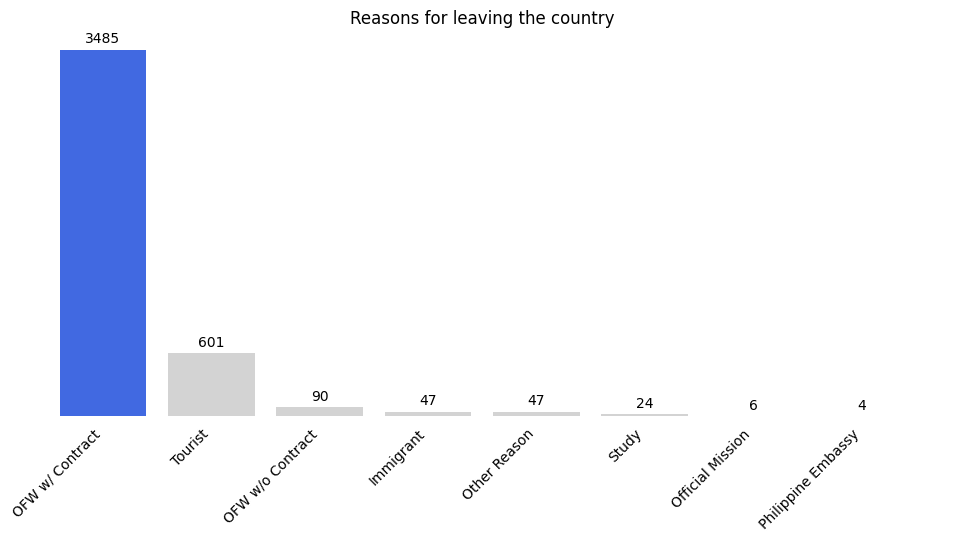

In [130]:
#| fig-cap: "Figure 1: Reasons for leaving the country"
total_per_reasons_for_leaving = df["reason_for_leaving"].value_counts()
xlabels = ["OFW w/ Contract", "Tourist", "OFW w/o Contract", "Immigrant", "Other Reason", "Study", "Official Mission", "Philippine Embassy"]

fig, ax = plt.subplots(figsize=(12, 5))

max_value = max(total_per_reasons_for_leaving.values)
bar_colors = ['lightgray' if val != max_value else 'royalblue' for val in total_per_reasons_for_leaving.values]

bars = ax.bar(xlabels,total_per_reasons_for_leaving.values, color=bar_colors, edgecolor='none')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.set_visible(False)
ax.tick_params(bottom=False)
plt.xticks(rotation=45, ha='right')

ax.bar_label(bars, label_type='edge', padding=3 , color='black', fontsize=10)

plt.title("Reasons for leaving the country")
plt.show()

Figure 1 illustrates the primary reasons Filipinos leave the country. The data reveals that the overwhelming majority travel for documented employment, with 'OFW w/ Contract' accounting for 3,485 respondents. Tourism is the second most common reason at 601 respondents. Meanwhile, all other categories, such as traveling without a contract (90), immigration (47), and study (24), make up a very small fraction of the total volume.

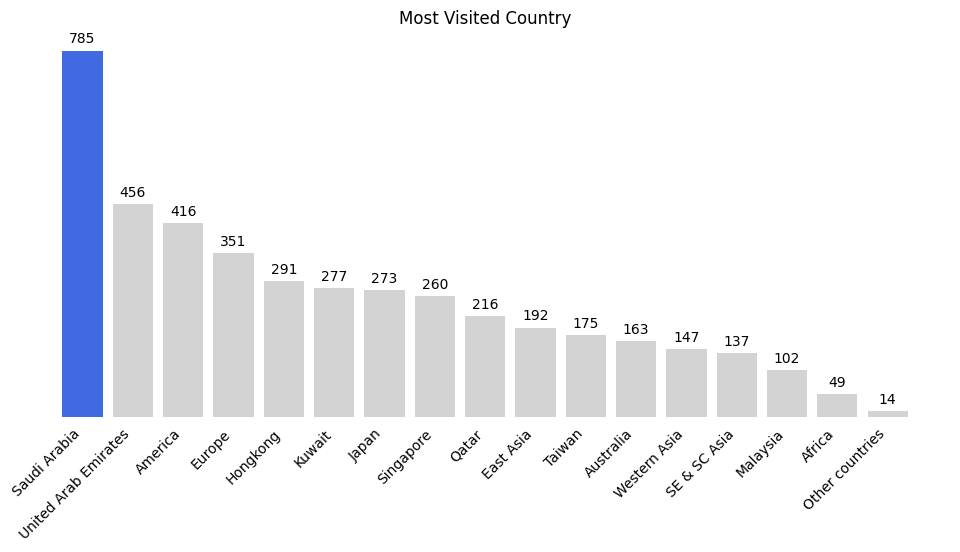

In [131]:
#| fig-cap: "Figure 2: Number of Overseas Filipino per Country"
total_per_destinations = df["destination_country"].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))

max_value = max(total_per_destinations.values)
bar_colors = ['lightgray' if val != max_value else 'royalblue' for val in total_per_destinations.values]

bars = ax.bar(total_per_destinations.index, total_per_destinations.values, color=bar_colors, edgecolor='none')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.set_visible(False)
ax.tick_params(bottom=False)
plt.xticks(rotation=45, ha='right')

ax.bar_label(bars, label_type='edge', padding=3 , color='black', fontsize=10)

plt.title("Most Visited Country")
plt.show()


Figure 2 illustrates the distribution of Overseas Filipino Worker (OFW) destinations among the respondents. The data reveals a strong concentration in the Middle East, with Saudi Arabia being the leading destination by a significant margin (785 respondents). This is followed by the United Arab Emirates (456). Other major non-Middle Eastern destinations include the Americas (416) and Europe (351), while traditional Asian hubs like Hong Kong, Japan, and Singapore make up the middle tier of the distribution.

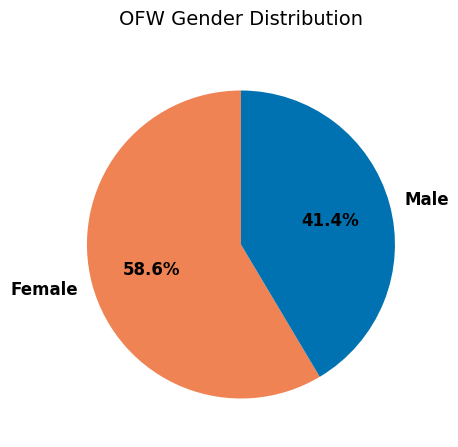

In [132]:
#| fig-cap: "Figure 3: Female vs. Male (Sex Ratio)"
sex_ofw = df["sex"].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
custom_colors = ["#EF8354", "#0072B2"]

ax.pie(
    sex_ofw.values,
    labels=sex_ofw.index,
    colors=custom_colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12, 'color': 'black', 'weight': 'bold'},
)

plt.title('OFW Gender Distribution', fontsize=14, pad=20)
plt.show()

Figure 3 illustrates the gender distribution of the surveyed Overseas Filipino Workers. The data indicates a notably female-majority workforce within this sample, with women comprising 58.6% of the respondents compared to 41.4% men.

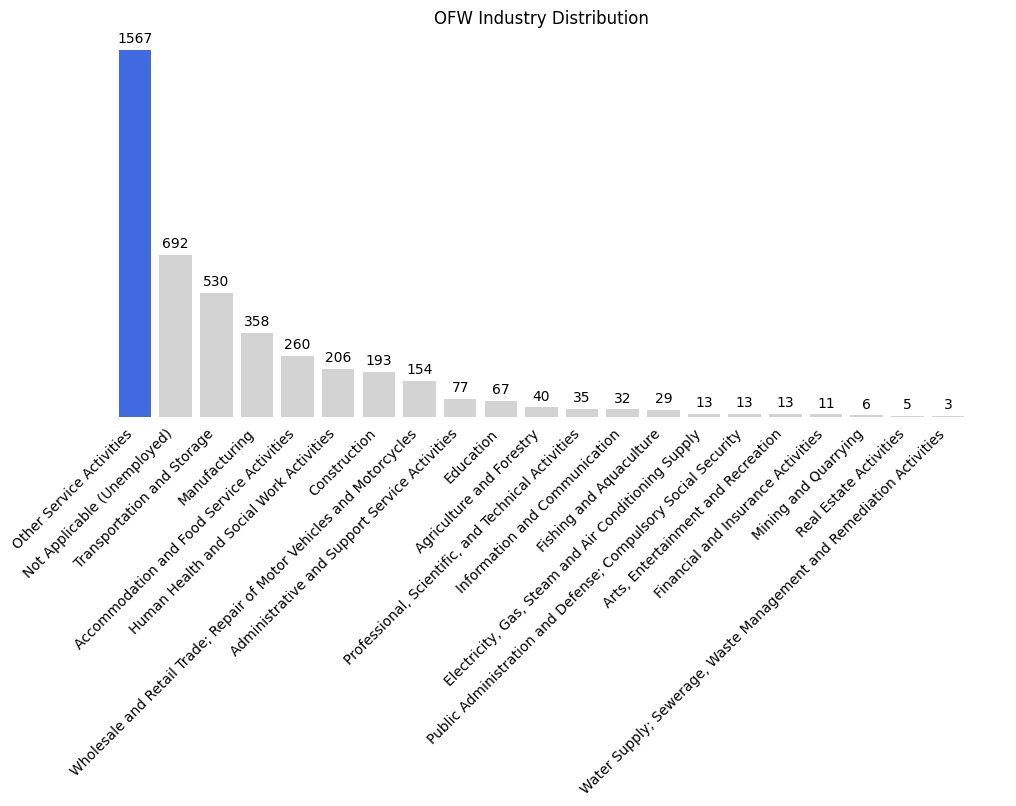

In [133]:
#| fig-cap: "Figure 4: OFW Industry Distribution"
overseas_industry_values = df["overseas_industry"].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))

max_value = max(overseas_industry_values.values)
bar_colors = ['lightgray' if val != max_value else 'royalblue' for val in overseas_industry_values.values]

bars = ax.bar(overseas_industry_values.index, overseas_industry_values.values, color=bar_colors, edgecolor='none')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.set_visible(False)
ax.tick_params(bottom=False)
plt.xticks(rotation=45, ha='right')

ax.bar_label(bars, label_type='edge', padding=3 , color='black', fontsize=10)

plt.title("OFW Industry Distribution")
plt.show()

Figure 4 illustrates the industry distribution among the surveyed OFWs. The data reveals a heavy concentration in 'Other Service Activities,' which dominates the workforce at 1,567 respondents. Notably, the second-largest category is 'Not Applicable (Unemployed)' with 692 individuals, suggesting a significant portion of the sample may be between contracts, seeking employment, or traveling as dependents. Specific traditional sectors such as Transportation and Storage (530) and Manufacturing (358) form the next tier of the workforce.

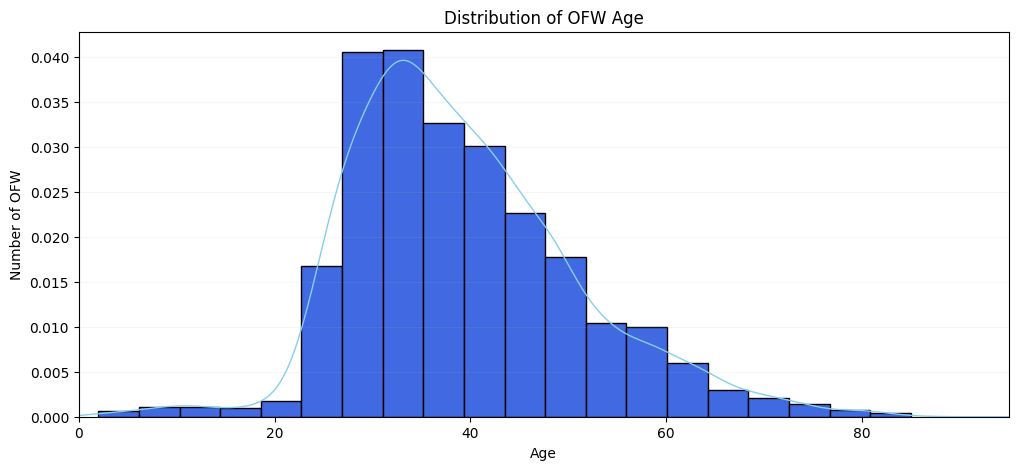

In [134]:
#| fig-cap: "Figure 5: OFW Age Distribution"
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(data=df, x='age', bins=20, color='royalblue', edgecolor='black', density=True)
plt.title("Distribution of OFW Age")
df['age'].plot(kind='kde', color='skyblue', linewidth=1, ax=ax)
plt.xlabel('Age')
plt.ylabel('Number of OFW')
plt.grid(axis='y', alpha=0.10)
plt.xlim(0, df['age'].max() + 10)
plt.show()

Figure 5 illustrates the age distribution among the surveyed OFWs. The distribution is moderately right-skewed (skewness ≈ 0.64), suggesting that while the bulk of the workforce consists of younger adults, there is a small but notable presence of older workers extending into their 80s.

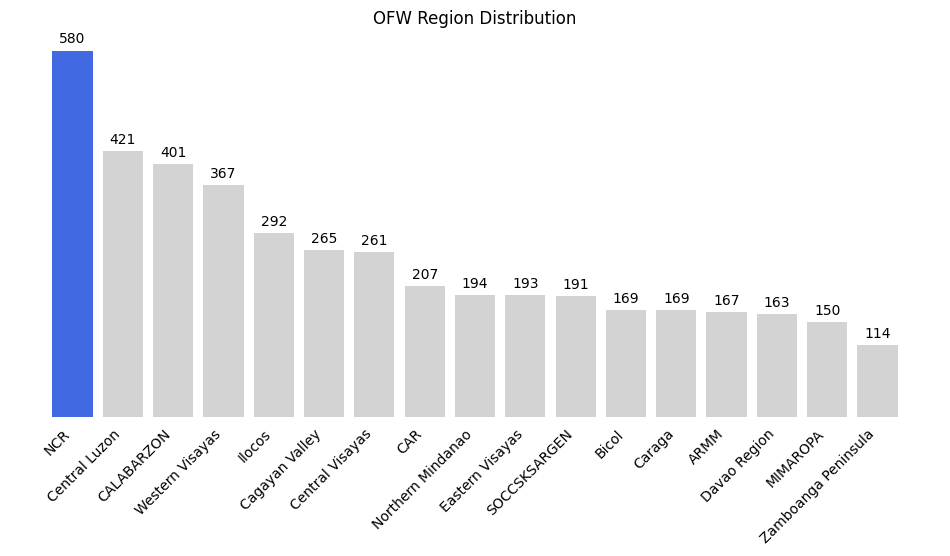

In [135]:
#| fig-cap: "Figure 6: OFW Region Distribution"
region_values = df["region"].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))

max_value = max(region_values.values)
bar_colors = ['lightgray' if val != max_value else 'royalblue' for val in region_values.values]

bars = ax.bar(region_values.index, region_values.values, color=bar_colors, edgecolor='none')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.set_visible(False)
ax.tick_params(bottom=False)
plt.xticks(rotation=45, ha='right')

ax.bar_label(bars, label_type='edge', padding=3 , color='black', fontsize=10)

plt.title("OFW Region Distribution")
plt.show()

Figure 6 illustrates the geographical origins of the surveyed OFWs. The National Capital Region serves as the primary source of overseas labor (580 respondents), followed closely by Central Luzon and CALABARZON, demonstrating that the bulk of the surveyed workforce originates from the country's most highly urbanized centers.

# Bivariate & Multivariate Analysis

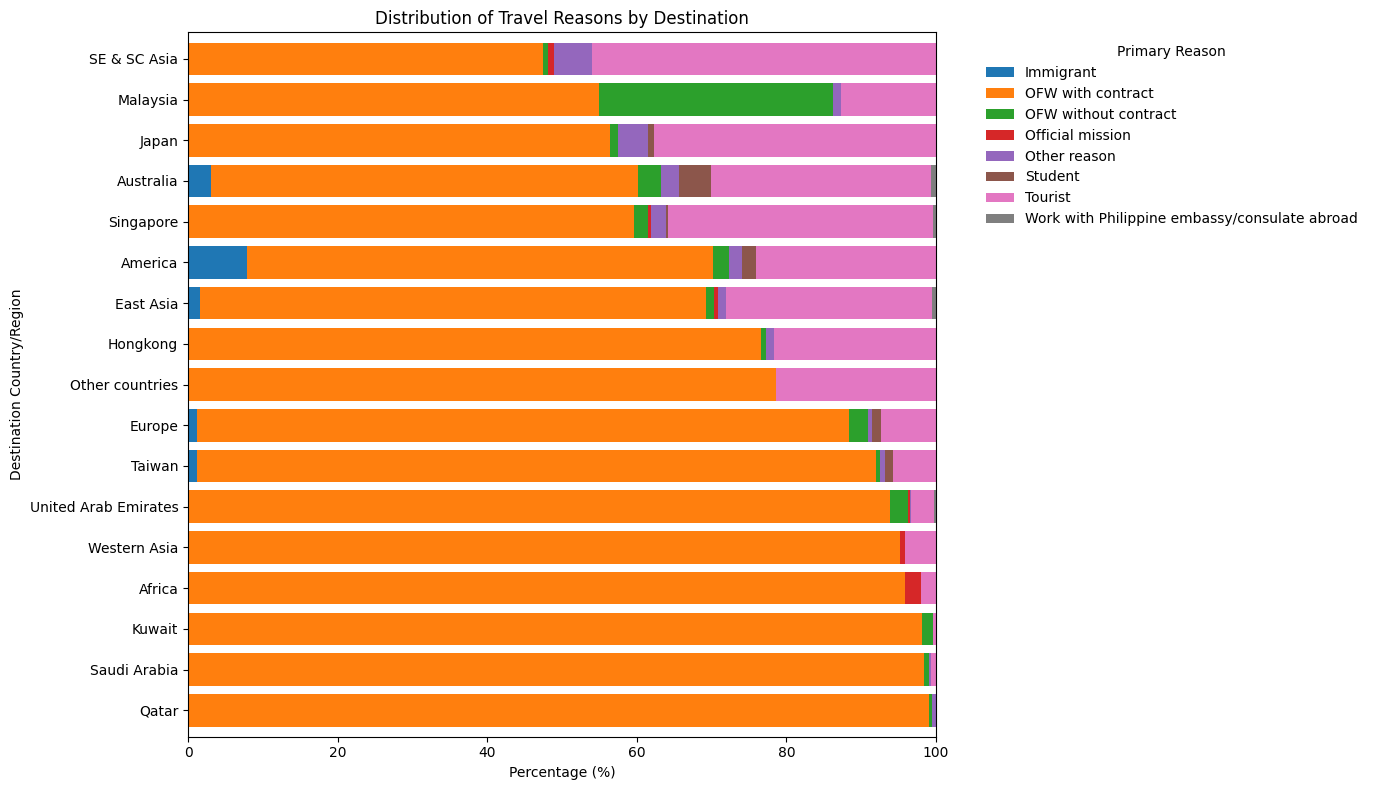

In [136]:
#| fig-cap: "Figure 7: Distribution of Travel Reasons by Destination"
import pandas as pd
import matplotlib.pyplot as plt

cross_tab = pd.crosstab(df['destination_country'], df['reason_for_leaving'], normalize='index') * 100
total_order = cross_tab.sort_values(by=cross_tab.max().idxmax(), ascending=False).index
cross_tab = cross_tab.loc[total_order]

cross_tab.plot(
    kind='barh',
    stacked=True,
    figsize=(14, 8),
    width=0.8,
)

plt.title('Distribution of Travel Reasons by Destination')
plt.xlabel('Percentage (%)')
plt.ylabel('Destination Country/Region')

plt.legend(title='Primary Reason', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()

plt.show()

Figure 7 presents a stacked bar chart illustrating the distribution of travel reasons across different destination countries. It highlights that for most destinations, "OFW w/ Contract" is the predominant reason for leaving, reinforcing the earlier observation that the majority of Filipinos travel for documented employment. However, some destinations show a higher proportion of "Tourist" or "Immigrant" reasons, indicating variations in migration patterns depending on the country.

sex                                                    Female        Male
overseas_industry                                                        
Accommodation and Food Service Activities           37.692308   62.307692
Administrative and Support Service Activities       58.441558   41.558442
Agriculture and Forestry                            37.500000   62.500000
Arts, Entertainment and Recreation                  46.153846   53.846154
Construction                                         5.181347   94.818653
Education                                           77.611940   22.388060
Electricity, Gas, Steam and Air Conditioning Su...   0.000000  100.000000
Financial and Insurance Activities                  63.636364   36.363636
Fishing and Aquaculture                              0.000000  100.000000
Human Health and Social Work Activities             74.271845   25.728155
Information and Communication                       31.250000   68.750000
Manufacturing                         

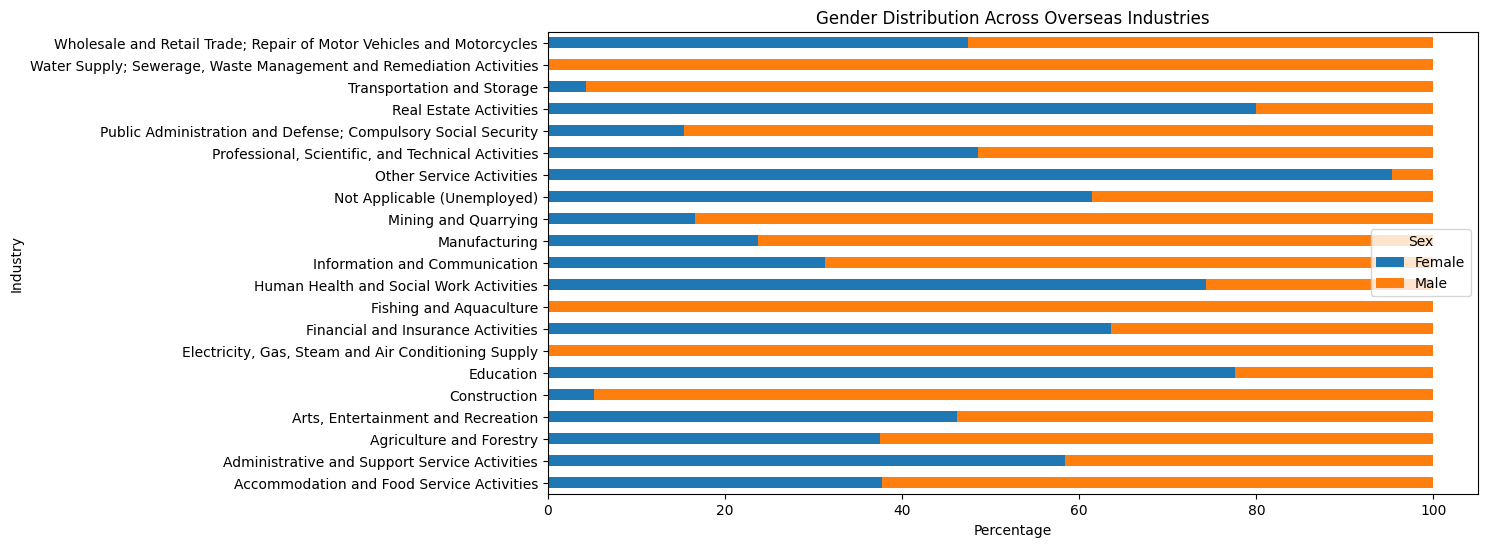

In [137]:
#| fig-cap: "Figure 8: Gender Distribution Across Overseas Industries"
# Create a percentage cross-tabulation table
cross_tab = pd.crosstab(df['overseas_industry'], df['sex'], normalize='index') * 100
print(cross_tab)

# Stacked Bar Chart visualization
cross_tab.plot(kind='barh', stacked=True, figsize=(12, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Gender Distribution Across Overseas Industries')
plt.xlabel('Percentage')
plt.ylabel('Industry')
plt.legend(title='Sex')
plt.show()

Figure 8 displays the gender distribution across various overseas industries. This stacked bar chart reveals significant gender disparities in certain sectors. For instance, some industries might be heavily dominated by female workers (e.g., "Other Service Activities" often includes domestic work and caregiving), while others might show a male majority (e.g., "Construction" or "Transportation and Storage"). The "Not Applicable (Unemployed)" category also shows its own gender split, which could indicate differences in employment seeking behaviors or opportunities for men and women.

C:\Users\Joseph Rey\AppData\Local\Temp\ipykernel_31156\2010470079.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_remittance.values, y=country_remittance.index, palette='coolwarm')


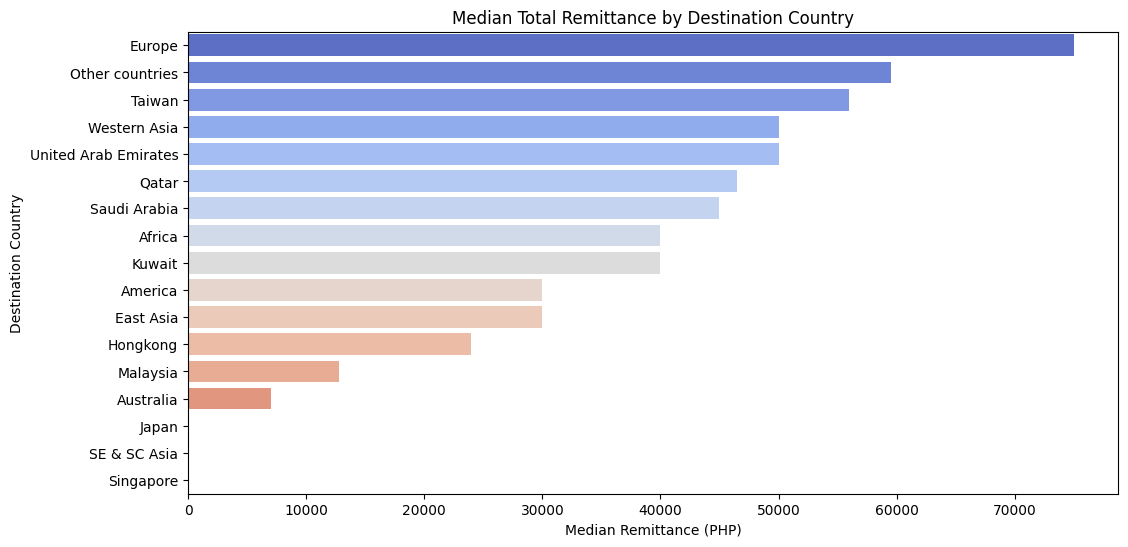

In [138]:
#| fig-cap: "Figure 9: Median Total Remittance by Destination Country"
country_remittance = df.groupby('destination_country')['total_remittance'].median().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_remittance.values, y=country_remittance.index, palette='coolwarm')
plt.title('Median Total Remittance by Destination Country')
plt.xlabel('Median Remittance (PHP)')
plt.ylabel('Destination Country')
plt.show()

Figure 9 illustrates the median total remittance sent by OFWs, broken down by their destination country. This bar plot highlights which countries are associated with higher or lower remittance flows. Destinations with higher median remittances could indicate better earning opportunities, higher cost of living, or stronger cultural ties encouraging more financial support to families back home. Conversely, lower median remittances might suggest less lucrative job markets or different financial priorities.

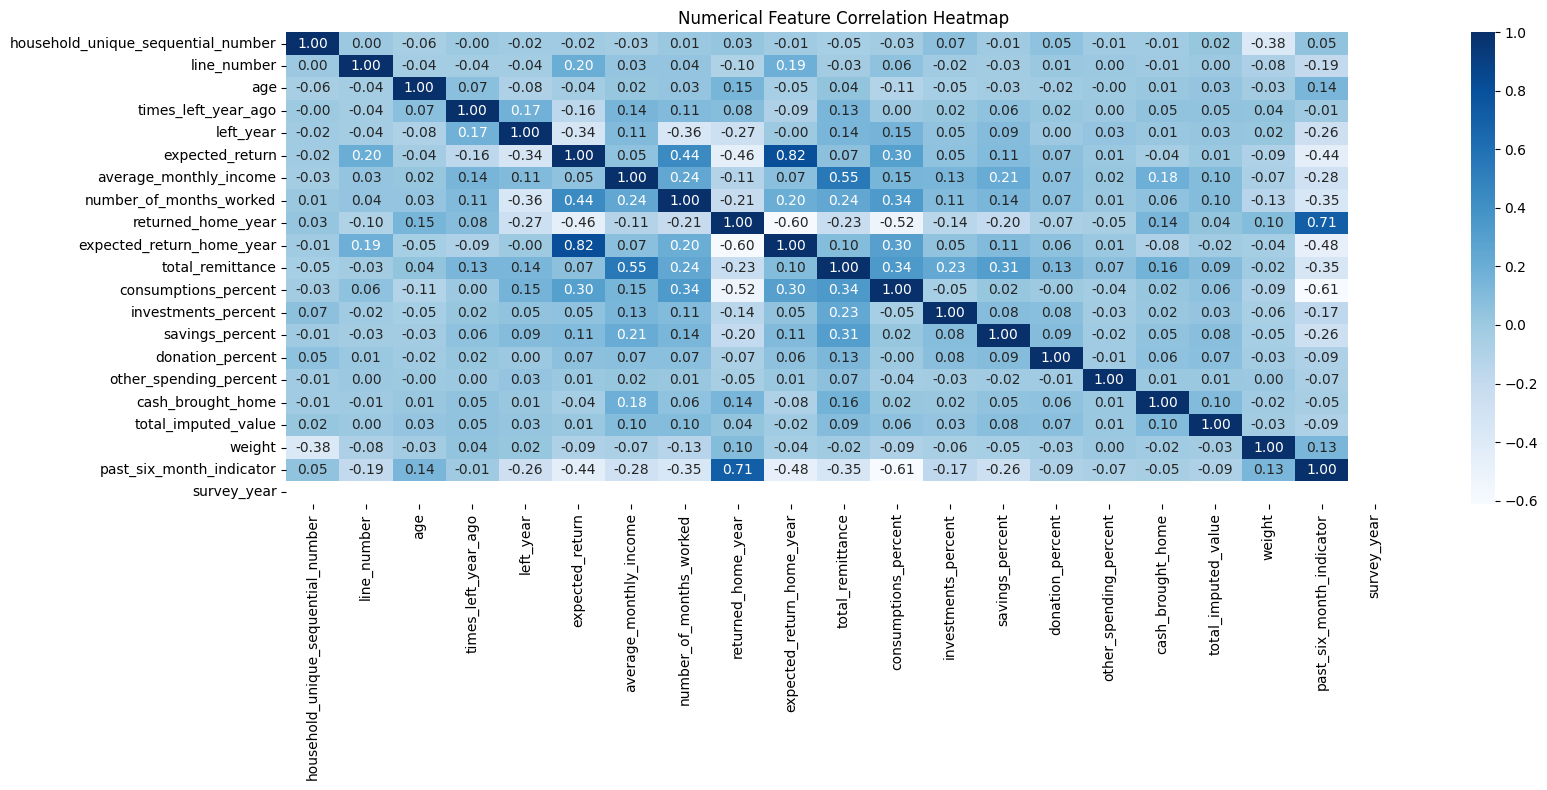

In [139]:
#| fig-cap: "Figure 10: Numerical Feature Correlation Heatmap"
numeric_cols = df.select_dtypes(include=['number']).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(17, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues', cbar=True)
plt.title('Numerical Feature Correlation Heatmap')
# Explicitly handles layout clipping for long labels
plt.tight_layout()
plt.show()

Figure 10 presents a heatmap of the correlation matrix for all numerical features in the dataset. This visualization helps identify relationships between different quantitative variables. Strong positive correlations (values close to 1) indicate that two variables tend to increase or decrease together, while strong negative correlations (values close to -1) suggest an inverse relationship. Correlations close to 0 imply a weak linear relationship. This heatmap is crucial for understanding potential multicollinearity among features, which is important for subsequent machine learning model building, and for identifying key drivers of variables like `total_remittance` or `average_monthly_income`.

C:\Users\Joseph Rey\AppData\Local\Temp\ipykernel_31156\1510726419.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_allocations.values, y=[col.replace('_', ' ').title() for col in avg_allocations.index], palette='pastel')


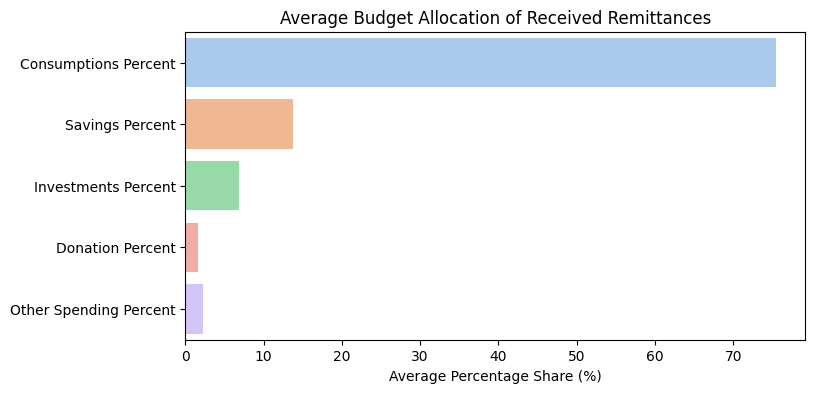

In [140]:
#| fig-cap: "Figure 11: Average Budget Allocation of Received Remittances"
spending_headers = ['consumptions_percent', 'savings_percent', 'investments_percent', 'donation_percent', 'other_spending_percent']

# Calculate national average breakdown among households that receive remittances
avg_allocations = df[df['remittance_received'] == 'With Remittance'][spending_headers].mean()

# Visualize with a clean horizontal bar layout
plt.figure(figsize=(8, 4))
sns.barplot(x=avg_allocations.values, y=[col.replace('_', ' ').title() for col in avg_allocations.index], palette='pastel')
plt.title('Average Budget Allocation of Received Remittances')
plt.xlabel('Average Percentage Share (%)')
plt.show()

Figure 11 illustrates the average allocation of received remittances across different spending categories. This bar plot provides insight into how OFW families utilize the money sent home. It shows the percentage of remittances typically spent on consumptions, savings, investments, donations, and other categories. This breakdown is vital for understanding the economic impact of remittances on household welfare and local economies, highlighting whether the funds are primarily used for daily needs, long-term financial security, or community support.

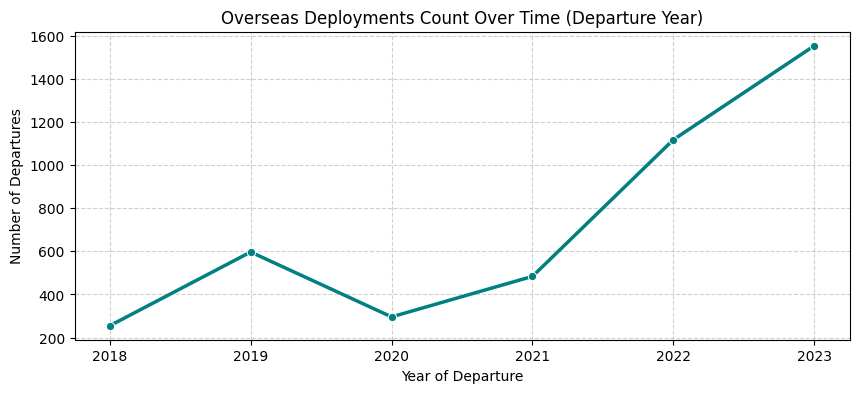

In [141]:
#| fig-cap: "Figure 12: Overseas Deployments Count Over Time (Departure Year)"
yearly_trends = df['left_year'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
sns.lineplot(x=yearly_trends.index.astype(str), y=yearly_trends.values, marker='o', linewidth=2.5, color='teal')
plt.title('Overseas Deployments Count Over Time (Departure Year)')
plt.xlabel('Year of Departure')
plt.ylabel('Number of Departures')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [142]:
df.to_csv("./dataset/clean_data.csv")

# Machine Learning

## OBJECTIVE 1: PREDICTIVE REMITTANCE MODELING (Regression)

This section focuses on building regression models to predict the total cash remittance sent by Overseas Filipino Workers (OFWs). The models will leverage features such as the destination country, duration of work (in months), and average monthly income to forecast remittance amounts. Ensemble regression techniques, specifically Random Forest and XGBoost, will be employed and evaluated using 5-fold cross-validation.

### Data Preparation for Remittance Prediction

In [143]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression # Import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Filter data for OFWs who sent remittances
remittance_df = df[df['remittance_received'] == 'With Remittance'].copy()

# Define features (X) and target (y)
features = ['destination_country', 'number_of_months_worked', '  ']
target = 'total_remittance'

# Drop rows with NaN values in the selected features or target
remittance_df.dropna(subset=features + [target], inplace=True)

X = remittance_df[features]
y = remittance_df[target]

# Encode 'destination_country' using LabelEncoder for tree-based models
# One-hot encoding is also an option, but LabelEncoder can work with tree-based models
# and keeps the feature matrix smaller.
le = LabelEncoder()
X['destination_country_encoded'] = le.fit_transform(X['destination_country'])
X = X.drop(columns=['destination_country'])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preparation complete for Remittance Prediction.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")


Data preparation complete for Remittance Prediction.
Shape of X_train: (2290, 3)
Shape of y_train: (2290,)
Shape of X_test: (573, 3)
Shape of y_test: (573,)


### Model Training and Evaluation

#### Random Forest Regressor

In [144]:
# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")


Random Forest Regressor Evaluation:
Mean Absolute Error (MAE): 51123.20
Mean Squared Error (MSE): 6490886064.94
Root Mean Squared Error (RMSE): 80566.04
R-squared (R2): 0.12


#### XGBoost Regressor

In [145]:
# Initialize XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"R-squared (R2): {r2_xgb:.2f}")


XGBoost Regressor Evaluation:
Mean Absolute Error (MAE): 52966.86
Mean Squared Error (MSE): 8460902217.44
Root Mean Squared Error (RMSE): 91983.16
R-squared (R2): -0.15


#### Linear Regression

In [146]:
# Initialize Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"R-squared (R2): {r2_lr:.2f}")


Linear Regression Evaluation:
Mean Absolute Error (MAE): 48056.75
Mean Squared Error (MSE): 5348230678.02
Root Mean Squared Error (RMSE): 73131.60
R-squared (R2): 0.27


### 5-Fold Cross-Validation

#### Random Forest Cross-Validation

In [147]:
# Perform 5-fold cross-validation for Random Forest
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_scores = cross_val_score(rf_model, X, y, cv=kf, scoring='r2', n_jobs=-1)

print("Random Forest Cross-Validation R-squared Scores:")
print(rf_cv_scores)
print(f"Mean CV R-squared: {np.mean(rf_cv_scores):.2f}")
print(f"Standard Deviation of CV R-squared: {np.std(rf_cv_scores):.2f}")


Random Forest Cross-Validation R-squared Scores:
[0.12639065 0.30781372 0.15039101 0.20466174 0.24928545]
Mean CV R-squared: 0.21
Standard Deviation of CV R-squared: 0.07


#### XGBoost Cross-Validation

In [148]:
# Perform 5-fold cross-validation for XGBoost
xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=kf, scoring='r2', n_jobs=-1)

print("XGBoost Cross-Validation R-squared Scores:")
print(xgb_cv_scores)
print(f"Mean CV R-squared: {np.mean(xgb_cv_scores):.2f}")
print(f"Standard Deviation of CV R-squared: {np.std(xgb_cv_scores):.2f}")


XGBoost Cross-Validation R-squared Scores:
[-0.15016763  0.22886434  0.13600629  0.14376673  0.17714561]
Mean CV R-squared: 0.11
Standard Deviation of CV R-squared: 0.13


#### Linear Regression Cross-Validation

In [149]:
# Perform 5-fold cross-validation for Linear Regression
lr_cv_scores = cross_val_score(lr_model, X, y, cv=kf, scoring='r2', n_jobs=-1)

print("Linear Regression Cross-Validation R-squared Scores:")
print(lr_cv_scores)
print(f"Mean CV R-squared: {np.mean(lr_cv_scores):.2f}")
print(f"Standard Deviation of CV R-squared: {np.std(lr_cv_scores):.2f}")


Linear Regression Cross-Validation R-squared Scores:
[0.27296621 0.48079582 0.26721568 0.38341372 0.3597853 ]
Mean CV R-squared: 0.35
Standard Deviation of CV R-squared: 0.08


### Remittance Forecast Output

Based on the evaluation, the model with the higher mean cross-validation R-squared score would be chosen for forecasting. For demonstration, we will use the trained XGBoost model to predict remittances for a sample input.

Let's assume we want to predict the remittance for an OFW:
- Destination Country: Saudi Arabia
- Number of Months Worked: 12
- Average Monthly Income: 50000 PHP

In [150]:
# Create a sample input for prediction
sample_data = pd.DataFrame({
    'destination_country': ['Saudi Arabia'],
    'number_of_months_worked': [12],
    'average_monthly_income': [50000]
})

# Encode the destination country for the sample data
sample_data['destination_country_encoded'] = le.transform(sample_data['destination_country'])
sample_data = sample_data.drop(columns=['destination_country'])

# Predict using the chosen model (e.g., XGBoost)
predicted_remittance = xgb_model.predict(sample_data)

print(f"Predicted Total Cash Remittance for the sample OFW: PHP {predicted_remittance[0]:.2f}")


Predicted Total Cash Remittance for the sample OFW: PHP 99170.63


## OBJECTIVE 2: LABOR MARKET & GENDER DISPARITIES (Classification)

This objective aims to analyze labor market and gender disparities among Overseas Filipino Workers (OFWs). It involves segmenting data by sex and highest educational attainment, performing cross-tabulations with overseas occupations, and using statistical tests to identify significant relationships. A key focus will be on quantifying underemployment, specifically identifying degree holders working in elementary occupations.

### Data Segmentation and Cross-Tabulation

In [151]:
from scipy.stats import chi2_contingency

# Filter for OFWs who have worked overseas
worked_overseas_df = df[df['ever_worked'] == True].copy()

# Drop rows with NaN values in the relevant columns for this objective
worked_overseas_df.dropna(subset=['sex', 'highest_grade_completed', 'overseas_industry'], inplace=True)

# Cross-tabulation: Gender vs. Overseas Industry
gender_industry_crosstab = pd.crosstab(worked_overseas_df['sex'], worked_overseas_df['overseas_industry'])
print("Cross-Tabulation: Gender vs. Overseas Industry\n")
print(gender_industry_crosstab)
print("\n" + "="*70 + "\n")

# Cross-tabulation: Highest Grade Completed vs. Overseas Industry
education_industry_crosstab = pd.crosstab(worked_overseas_df['highest_grade_completed'], worked_overseas_df['overseas_industry'])
print("Cross-Tabulation: Highest Grade Completed vs. Overseas Industry\n")
print(education_industry_crosstab)
print("\n" + "="*70 + "\n")


Cross-Tabulation: Gender vs. Overseas Industry

overseas_industry  Accommodation and Food Service Activities  \
sex                                                            
Female                                                    98   
Male                                                     162   

overseas_industry  Administrative and Support Service Activities  \
sex                                                                
Female                                                        45   
Male                                                          32   

overseas_industry  Agriculture and Forestry  \
sex                                           
Female                                   15   
Male                                     25   

overseas_industry  Arts, Entertainment and Recreation  Construction  \
sex                                                                   
Female                                              6            10   
Male                

### Statistical Validation: Chi-Square Test of Independence

The Chi-Square Test of Independence will be used to determine if there is a significant relationship between categorical variables (e.g., sex and overseas industry, or education level and overseas industry). A p-value less than 0.05 typically indicates a statistically significant relationship.

#### Chi-Square Test: Gender vs. Overseas Industry

In [152]:
chi2_gender_industry, p_gender_industry, dof_gender_industry, ex_gender_industry = chi2_contingency(gender_industry_crosstab)

print("Chi-Square Test: Gender vs. Overseas Industry")
print(f"Chi-Square Statistic: {chi2_gender_industry:.2f}")
print(f"P-value: {p_gender_industry:.3f}")
print(f"Degrees of Freedom: {dof_gender_industry}")

if p_gender_industry < 0.05:
    print("Conclusion: There is a statistically significant relationship between Gender and Overseas Industry.")
else:
    print("Conclusion: There is no statistically significant relationship between Gender and Overseas Industry.")
print("\n" + "="*70 + "\n")


Chi-Square Test: Gender vs. Overseas Industry
Chi-Square Statistic: 2096.55
P-value: 0.000
Degrees of Freedom: 19
Conclusion: There is a statistically significant relationship between Gender and Overseas Industry.




#### Chi-Square Test: Highest Grade Completed vs. Overseas Industry

In [153]:
chi2_education_industry, p_education_industry, dof_education_industry, ex_education_industry = chi2_contingency(education_industry_crosstab)

print("Chi-Square Test: Highest Grade Completed vs. Overseas Industry")
print(f"Chi-Square Statistic: {chi2_education_industry:.2f}")
print(f"P-value: {p_education_industry:.3f}")
print(f"Degrees of Freedom: {dof_education_industry}")

if p_education_industry < 0.05:
    print("Conclusion: There is a statistically significant relationship between Highest Grade Completed and Overseas Industry.")
else:
    print("Conclusion: There is no statistically significant relationship between Highest Grade Completed and Overseas Industry.")
print("\n" + "="*70 + "\n")


Chi-Square Test: Highest Grade Completed vs. Overseas Industry
Chi-Square Statistic: 1319.10
P-value: 0.000
Degrees of Freedom: 190
Conclusion: There is a statistically significant relationship between Highest Grade Completed and Overseas Industry.




### Quantifying Underemployment: Degree Holders in Elementary Occupations

This analysis identifies OFWs who possess a college degree or higher but are employed in elementary occupations, which are typically considered low-skilled. This helps to quantify the "brain drain" or underemployment among highly educated workers.

In [154]:
#| output: true
# Define categories for degree holders and elementary occupations
degree_holders = [
    "College undergraduate",
    "College graduate",
    "Post graduate"
]
elementary_occupations = "Elementary Occupations"

# Filter for degree holders in elementary occupations
underemployed_degree_holders = worked_overseas_df[
    (worked_overseas_df['highest_grade_completed'].isin(degree_holders)) &
    (worked_overseas_df['overseas_industry'] == elementary_occupations)
]

num_underemployed = len(underemployed_degree_holders)
total_degree_holders = worked_overseas_df[worked_overseas_df['highest_grade_completed'].isin(degree_holders)].shape[0]

print(f"Number of Degree Holders in Elementary Occupations: {num_underemployed}")
print(f"Total Number of Degree Holders (who worked overseas): {total_degree_holders}")

if total_degree_holders > 0:
    percentage_underemployed = (num_underemployed / total_degree_holders) * 100
    print(f"Percentage of Degree Holders in Elementary Occupations: {percentage_underemployed:.2f}%")
else:
    print("No degree holders found in the dataset who worked overseas.")

# Display a sample of underemployed individuals
if not underemployed_degree_holders.empty:
    print("\nSample of Underemployed Degree Holders:")
    print(underemployed_degree_holders[['sex', 'highest_grade_completed', 'overseas_industry', 'average_monthly_income']].head())
else:
    print("\nNo sample of underemployed individuals to display.")


Number of Degree Holders in Elementary Occupations: 0
Total Number of Degree Holders (who worked overseas): 1910
Percentage of Degree Holders in Elementary Occupations: 0.00%

No sample of underemployed individuals to display.


In [155]:
df

,region,household_unique_sequential_number,line_number,relationship,sex,age,times_left_year_ago,left_month,left_year,marital_status,...,total_imputed_value,weight,past_six_month_indicator,survey_year,province_code,spent_consumptions,spent_investments,spent_savings,spent_donations,spent_other
0,Ilocos,1,81,Other relative,Male,65,1,Mar,2023,Married,...,55000.0,463.1271,0,2023,Ilocos Norte,True,False,False,False,False
1,Ilocos,1,82,Other relative,Female,72,1,Mar,2023,Married,...,0.0,463.1271,0,2023,Ilocos Norte,False,False,False,False,False
2,Ilocos,1,83,Other relative,Female,30,1,Mar,2023,Single,...,0.0,463.1271,0,2023,Ilocos Norte,False,False,False,False,False
3,Ilocos,2,4,Child,Female,42,2,Sep,2023,Widowed,...,30000.0,456.8271,1,2023,Ilocos Norte,True,False,False,False,False
4,Ilocos,3,2,Spouse,Female,43,1,Apr,2023,Married,...,0.0,456.8271,1,2023,Ilocos Norte,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4299,ARMM,3697,2,Spouse,Female,29,1,Jun,2019,Married,...,0.0,294.8777,1,2023,BARMM63,True,False,False,False,False
4300,ARMM,3698,2,Spouse,Female,38,2,Oct,2022,Married,...,0.0,382.1495,1,2023,BARMM63,True,True,False,False,False
4301,ARMM,3699,2,Spouse,Female,48,2,May,2021,Married,...,0.0,345.1758,1,2023,BARMM63,True,False,False,False,False
4302,ARMM,3700,2,Spouse,Female,23,1,Mar,2019,Married,...,17000.0,294.2764,1,2023,BARMM63,True,False,False,False,False
